In [1]:
import os
import re
from collections import defaultdict

import ROOT
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from idm_plot_utils import *

setup_root_style()

INPUT = "root://cmseos.fnal.gov//store/group/lpcmetx/iDMe/Samples/Ntuples/signal_iDMmu_muonBranches_inclusive/2022EE/iDMmu"
TREE_NAME = "ntuples/outT"

OUTDIR = "matching_efficiency_existing_branches"
os.makedirs(OUTDIR, exist_ok=True)

MATCH_DR_MAX = 0.3

Welcome to JupyROOT 6.26/11


In [2]:
files, sample_to_files, samples = load_samples(INPUT)

Found 138 ROOT files
Found 20 grouped samples
Mchi-5p25_dMchi-0p5_ctau-1           nfiles = 8
Mchi-5p25_dMchi-0p5_ctau-10          nfiles = 8
Mchi-5p25_dMchi-0p5_ctau-100         nfiles = 8
Mchi-5p25_dMchi-0p5_ctau-1000        nfiles = 5
Mchi-10p5_dMchi-1p0_ctau-1           nfiles = 8
Mchi-10p5_dMchi-1p0_ctau-10          nfiles = 4
Mchi-10p5_dMchi-1p0_ctau-100         nfiles = 4
Mchi-10p5_dMchi-1p0_ctau-1000        nfiles = 7
Mchi-21p0_dMchi-2p0_ctau-1           nfiles = 7
Mchi-21p0_dMchi-2p0_ctau-10          nfiles = 8
Mchi-21p0_dMchi-2p0_ctau-100         nfiles = 7
Mchi-21p0_dMchi-2p0_ctau-1000        nfiles = 8
Mchi-31p5_dMchi-3p0_ctau-1           nfiles = 6
Mchi-31p5_dMchi-3p0_ctau-10          nfiles = 6
Mchi-31p5_dMchi-3p0_ctau-100         nfiles = 7
Mchi-31p5_dMchi-3p0_ctau-1000        nfiles = 8
Mchi-42p0_dMchi-4p0_ctau-1           nfiles = 6
Mchi-42p0_dMchi-4p0_ctau-10          nfiles = 8
Mchi-42p0_dMchi-4p0_ctau-100         nfiles = 7
Mchi-42p0_dMchi-4p0_ctau-1000        nfile

In [3]:
test_sample = samples[0]
ch = make_chain(sample_to_files[test_sample], tree_name=TREE_NAME)

branches = sorted([b.GetName() for b in ch.GetListOfBranches()])

for b in branches:
    bl = b.lower()
    if (
        "gensig" in bl
        or "genmuon" in bl
        or "genantimuon" in bl
        or "genparticle" in bl
    ) and (
        "mindr" in bl
        or "match" in bl
        or "valid" in bl
        or "charge" in bl
        or "pt" in bl
        or "eta" in bl
        or "phi" in bl
        or "id" in bl
        or "status" in bl
        or "mother" in bl
        or "lastcopy" in bl
    ):
        print(b)

GenParticle_ID
GenParticle_charge
GenParticle_eta
GenParticle_firstDifferentMotherID
GenParticle_isLastCopy
GenParticle_isLastCopyBeforeFSR
GenParticle_isPromptFinalState
GenParticle_motherID
GenParticle_phi
GenParticle_pt
GenParticle_status
GenSigAntiMuon_charge
GenSigAntiMuon_eta
GenSigAntiMuon_firstDifferentMotherID
GenSigAntiMuon_immediateMotherID
GenSigAntiMuon_isLastCopy
GenSigAntiMuon_isLastCopyBeforeFSR
GenSigAntiMuon_isPromptFinalState
GenSigAntiMuon_isValid
GenSigAntiMuon_matchDSAMuonIdx
GenSigAntiMuon_matchIdxGlobal
GenSigAntiMuon_matchIdxLocal
GenSigAntiMuon_matchRecoMuonIdx
GenSigAntiMuon_matchType
GenSigAntiMuon_matched
GenSigAntiMuon_minDrToDSAMuon
GenSigAntiMuon_minDrToRecoMuon
GenSigAntiMuon_motherID
GenSigAntiMuon_phi
GenSigAntiMuon_pt
GenSigAntiMuon_status
GenSigDimuon_isValid
GenSigMuon_charge
GenSigMuon_eta
GenSigMuon_firstDifferentMotherID
GenSigMuon_immediateMotherID
GenSigMuon_isLastCopy
GenSigMuon_isLastCopyBeforeFSR
GenSigMuon_isPromptFinalState
GenSigMuon_isV

In [4]:
def has_branch(chain, name):
    return bool(chain.GetBranch(name))


def first_existing_branch(chain, candidates, required=False):
    for c in candidates:
        if has_branch(chain, c):
            return c

    if required:
        print("Missing required branch. Tried:")
        for c in candidates:
            print("  ", c)
        raise RuntimeError("Required branch not found")

    return None


def vec_size(v):
    if v is None:
        return 0
    if hasattr(v, "size"):
        return int(v.size())
    return len(v)


def scalar_bool(x):
    try:
        return bool(int(x))
    except Exception:
        return bool(x)


def scalar_float(x, default=-999.0):
    try:
        return float(x)
    except Exception:
        return default


def scalar_int(x, default=-999):
    try:
        return int(x)
    except Exception:
        return default


def get_scalar(chain, branch, default=-999):
    if branch is None:
        return default
    try:
        return getattr(chain, branch)
    except Exception:
        return default


def get_vec(chain, branch):
    if branch is None:
        return None
    try:
        return getattr(chain, branch)
    except Exception:
        return None


def matched_from_min_dr(min_dr, threshold=0.3):
    return int(min_dr >= 0.0 and min_dr < threshold)


def either_match_from_min_dr(min_dr_pf, min_dr_dsa, threshold=0.3):
    return int(
        (min_dr_pf >= 0.0 and min_dr_pf < threshold)
        or
        (min_dr_dsa >= 0.0 and min_dr_dsa < threshold)
    )


def either_min_dr(min_dr_pf, min_dr_dsa):
    vals = []
    if min_dr_pf >= 0.0:
        vals.append(min_dr_pf)
    if min_dr_dsa >= 0.0:
        vals.append(min_dr_dsa)
    return min(vals) if vals else 999.0

In [5]:
def detect_matching_branches(chain):
    br = {}

    # Common event-level branches
    br["run"] = first_existing_branch(chain, ["runNum", "run"])
    br["lumi"] = first_existing_branch(chain, ["lumiSec", "lumi"])
    br["event"] = first_existing_branch(chain, ["eventNum", "event"])
    br["dimuon_dr"] = first_existing_branch(chain, ["genSigDimuon_dr"], required=True)
    br["dimuon_valid"] = first_existing_branch(chain, ["GenSigDimuon_isValid", "genSigDimuon_isValid"])

    # Scalar GenSig branches
    br["GenSigMuon_valid"] = first_existing_branch(chain, ["GenSigMuon_isValid"], required=True)
    br["GenSigMuon_charge"] = first_existing_branch(chain, ["GenSigMuon_charge"], required=True)
    br["GenSigMuon_pt"] = first_existing_branch(chain, ["GenSigMuon_pt"], required=True)
    br["GenSigMuon_minDrReco"] = first_existing_branch(chain, ["GenSigMuon_minDrToRecoMuon"], required=True)
    br["GenSigMuon_minDrDSA"] = first_existing_branch(chain, ["GenSigMuon_minDrToDSAMuon"], required=True)

    br["GenSigAntiMuon_valid"] = first_existing_branch(chain, ["GenSigAntiMuon_isValid"], required=True)
    br["GenSigAntiMuon_charge"] = first_existing_branch(chain, ["GenSigAntiMuon_charge"], required=True)
    br["GenSigAntiMuon_pt"] = first_existing_branch(chain, ["GenSigAntiMuon_pt"], required=True)
    br["GenSigAntiMuon_minDrReco"] = first_existing_branch(chain, ["GenSigAntiMuon_minDrToRecoMuon"], required=True)
    br["GenSigAntiMuon_minDrDSA"] = first_existing_branch(chain, ["GenSigAntiMuon_minDrToDSAMuon"], required=True)

    # Inclusive Gen-muon collection candidates.
    #
    # Use whichever naming exists in your ntuples.
    # This avoids recomputing matching in Python.
    br["GenMuon_pt"] = first_existing_branch(
        chain,
        [
            "GenMuon_pt",
            "genMuon_pt",
            "GenMuonPt",
            "genMuonPt",
        ],
    )

    br["GenMuon_charge"] = first_existing_branch(
        chain,
        [
            "GenMuon_charge",
            "genMuon_charge",
            "GenMuonCharge",
            "genMuonCharge",
        ],
    )

    br["GenMuon_minDrReco"] = first_existing_branch(
        chain,
        [
            "GenMuon_minDrToRecoMuon",
            "genMuon_minDrToRecoMuon",
            "GenMuonMinDrToRecoMuon",
            "genMuonMinDrToRecoMuon",
        ],
    )

    br["GenMuon_minDrDSA"] = first_existing_branch(
        chain,
        [
            "GenMuon_minDrToDSAMuon",
            "genMuon_minDrToDSAMuon",
            "GenMuonMinDrToDSAMuon",
            "genMuonMinDrToDSAMuon",
        ],
    )

    br["GenAntiMuon_pt"] = first_existing_branch(
        chain,
        [
            "GenAntiMuon_pt",
            "genAntiMuon_pt",
            "GenAntiMuonPt",
            "genAntiMuonPt",
        ],
    )

    br["GenAntiMuon_charge"] = first_existing_branch(
        chain,
        [
            "GenAntiMuon_charge",
            "genAntiMuon_charge",
            "GenAntiMuonCharge",
            "genAntiMuonCharge",
        ],
    )

    br["GenAntiMuon_minDrReco"] = first_existing_branch(
        chain,
        [
            "GenAntiMuon_minDrToRecoMuon",
            "genAntiMuon_minDrToRecoMuon",
            "GenAntiMuonMinDrToRecoMuon",
            "genAntiMuonMinDrToRecoMuon",
        ],
    )

    br["GenAntiMuon_minDrDSA"] = first_existing_branch(
        chain,
        [
            "GenAntiMuon_minDrToDSAMuon",
            "genAntiMuon_minDrToDSAMuon",
            "GenAntiMuonMinDrToDSAMuon",
            "genAntiMuonMinDrToDSAMuon",
        ],
    )

    return br


br_test = detect_matching_branches(ch)

for k, v in br_test.items():
    print(f"{k:30s} : {v}")

run                            : runNum
lumi                           : lumiSec
event                          : eventNum
dimuon_dr                      : genSigDimuon_dr
dimuon_valid                   : GenSigDimuon_isValid
GenSigMuon_valid               : GenSigMuon_isValid
GenSigMuon_charge              : GenSigMuon_charge
GenSigMuon_pt                  : GenSigMuon_pt
GenSigMuon_minDrReco           : GenSigMuon_minDrToRecoMuon
GenSigMuon_minDrDSA            : GenSigMuon_minDrToDSAMuon
GenSigAntiMuon_valid           : GenSigAntiMuon_isValid
GenSigAntiMuon_charge          : GenSigAntiMuon_charge
GenSigAntiMuon_pt              : GenSigAntiMuon_pt
GenSigAntiMuon_minDrReco       : GenSigAntiMuon_minDrToRecoMuon
GenSigAntiMuon_minDrDSA        : GenSigAntiMuon_minDrToDSAMuon
GenMuon_pt                     : None
GenMuon_charge                 : None
GenMuon_minDrReco              : None
GenMuon_minDrDSA               : None
GenAntiMuon_pt                 : None
GenAntiMuon_charge        

In [6]:
test_sample = samples[0]
ch_test = make_chain(sample_to_files[test_sample], tree_name=TREE_NAME)

branches = sorted([b.GetName() for b in ch_test.GetListOfBranches()])

for b in branches:
    bl = b.lower()
    if (
        "gensig" in bl
        or "genparticle" in bl
        or "recomuon" in bl
        or "recodsa" in bl
    ) and (
        "mindr" in bl
        or "match" in bl
        or "charge" in bl
        or "pt" in bl
        or "eta" in bl
        or "phi" in bl
        or "valid" in bl
        or "status" in bl
        or "mother" in bl
        or "lastcopy" in bl
    ):
        print(b)

GenParticle_charge
GenParticle_eta
GenParticle_firstDifferentMotherID
GenParticle_isLastCopy
GenParticle_isLastCopyBeforeFSR
GenParticle_isPromptFinalState
GenParticle_motherID
GenParticle_phi
GenParticle_pt
GenParticle_status
GenSigAntiMuon_charge
GenSigAntiMuon_eta
GenSigAntiMuon_firstDifferentMotherID
GenSigAntiMuon_immediateMotherID
GenSigAntiMuon_isLastCopy
GenSigAntiMuon_isLastCopyBeforeFSR
GenSigAntiMuon_isPromptFinalState
GenSigAntiMuon_isValid
GenSigAntiMuon_matchDSAMuonIdx
GenSigAntiMuon_matchIdxGlobal
GenSigAntiMuon_matchIdxLocal
GenSigAntiMuon_matchRecoMuonIdx
GenSigAntiMuon_matchType
GenSigAntiMuon_matched
GenSigAntiMuon_minDrToDSAMuon
GenSigAntiMuon_minDrToRecoMuon
GenSigAntiMuon_motherID
GenSigAntiMuon_phi
GenSigAntiMuon_pt
GenSigAntiMuon_status
GenSigDimuon_isValid
GenSigMuon_charge
GenSigMuon_eta
GenSigMuon_firstDifferentMotherID
GenSigMuon_immediateMotherID
GenSigMuon_isLastCopy
GenSigMuon_isLastCopyBeforeFSR
GenSigMuon_isPromptFinalState
GenSigMuon_isValid
GenSigMuon

In [12]:
def has_branch(chain, name):
    return bool(chain.GetBranch(name))


def first_existing_branch(chain, candidates, required=False):
    for name in candidates:
        if has_branch(chain, name):
            return name

    if required:
        print("Missing required branch. Tried:")
        for name in candidates:
            print("  ", name)
        raise RuntimeError("Required branch not found")

    return None


def scalar_bool(x):
    try:
        return bool(int(x))
    except Exception:
        return bool(x)


def scalar_float(x, default=-999.0):
    try:
        return float(x)
    except Exception:
        return default


def scalar_int(x, default=-999):
    try:
        return int(x)
    except Exception:
        return default


def vec_size(v):
    if v is None:
        return 0
    if hasattr(v, "size"):
        return int(v.size())
    return len(v)


def get_scalar(chain, branch_name, default=-999):
    if branch_name is None:
        return default

    try:
        return getattr(chain, branch_name)
    except Exception:
        return default


def get_vector(chain, branch_name):
    if branch_name is None:
        return None

    try:
        return getattr(chain, branch_name)
    except Exception:
        return None


def pdgid_to_charge(pid):
    """
    PDG convention:
      mu- has pdgId = 13, charge = -1
      mu+ has pdgId = -13, charge = +1
    """
    pid = int(pid)

    if pid == 13:
        return -1
    if pid == -13:
        return +1

    return 0


def matched_from_min_dr(min_dr, threshold=0.3):
    return int(min_dr >= 0.0 and min_dr < threshold)


def either_match_from_min_dr(min_dr_pf, min_dr_dsa, threshold=0.3):
    return int(
        (min_dr_pf >= 0.0 and min_dr_pf < threshold)
        or
        (min_dr_dsa >= 0.0 and min_dr_dsa < threshold)
    )


def either_min_dr(min_dr_pf, min_dr_dsa):
    vals = []

    if min_dr_pf >= 0.0:
        vals.append(min_dr_pf)

    if min_dr_dsa >= 0.0:
        vals.append(min_dr_dsa)

    return min(vals) if vals else 999.0


def root_delta_r(eta1, phi1, eta2, phi2):
    return float(ROOT.reco.deltaR(float(eta1), float(phi1), float(eta2), float(phi2)))


def closest_same_sign_reco_root_delta_r(
    gen_eta,
    gen_phi,
    gen_charge,
    reco_etas,
    reco_phis,
    reco_charges,
    dr_max=0.3,
):
    best_dr = 999.0
    best_idx = -1

    n_reco = vec_size(reco_etas)

    for i in range(n_reco):
        reco_charge = int(reco_charges[i])

        if reco_charge != int(gen_charge):
            continue

        dr = root_delta_r(
            gen_eta,
            gen_phi,
            float(reco_etas[i]),
            float(reco_phis[i]),
        )

        if dr < best_dr:
            best_dr = dr
            best_idx = i

    matched = int(best_idx >= 0 and best_dr < dr_max)

    return {
        "matched": matched,
        "min_dr": best_dr,
        "idx": best_idx,
    }

In [13]:
test_sample = samples[0]
ch_test = make_chain(sample_to_files[test_sample], tree_name=TREE_NAME)

branches = sorted([b.GetName() for b in ch_test.GetListOfBranches()])

for b in branches:
    bl = b.lower()
    if (
        "gensig" in bl
        or "genparticle" in bl
        or "genpart" in bl
        or "recomuon" in bl
        or "recodsa" in bl
    ) and (
        "mindr" in bl
        or "match" in bl
        or "charge" in bl
        or "pt" in bl
        or "eta" in bl
        or "phi" in bl
        or "valid" in bl
        or "status" in bl
        or "mother" in bl
        or "lastcopy" in bl
    ):
        print(b)

GenParticle_charge
GenParticle_eta
GenParticle_firstDifferentMotherID
GenParticle_isLastCopy
GenParticle_isLastCopyBeforeFSR
GenParticle_isPromptFinalState
GenParticle_motherID
GenParticle_phi
GenParticle_pt
GenParticle_status
GenSigAntiMuon_charge
GenSigAntiMuon_eta
GenSigAntiMuon_firstDifferentMotherID
GenSigAntiMuon_immediateMotherID
GenSigAntiMuon_isLastCopy
GenSigAntiMuon_isLastCopyBeforeFSR
GenSigAntiMuon_isPromptFinalState
GenSigAntiMuon_isValid
GenSigAntiMuon_matchDSAMuonIdx
GenSigAntiMuon_matchIdxGlobal
GenSigAntiMuon_matchIdxLocal
GenSigAntiMuon_matchRecoMuonIdx
GenSigAntiMuon_matchType
GenSigAntiMuon_matched
GenSigAntiMuon_minDrToDSAMuon
GenSigAntiMuon_minDrToRecoMuon
GenSigAntiMuon_motherID
GenSigAntiMuon_phi
GenSigAntiMuon_pt
GenSigAntiMuon_status
GenSigDimuon_isValid
GenSigMuon_charge
GenSigMuon_eta
GenSigMuon_firstDifferentMotherID
GenSigMuon_immediateMotherID
GenSigMuon_isLastCopy
GenSigMuon_isLastCopyBeforeFSR
GenSigMuon_isPromptFinalState
GenSigMuon_isValid
GenSigMuon

In [16]:
def detect_branches(chain):
    br = {}

    # Event info
    br["run"] = first_existing_branch(chain, ["runNum", "run"])
    br["lumi"] = first_existing_branch(chain, ["lumiSec", "lumi"])
    br["event"] = first_existing_branch(chain, ["eventNum", "event"])

    # GenSig dimuon
    br["GenSigDimuon_isValid"] = first_existing_branch(
        chain,
        ["GenSigDimuon_isValid", "genSigDimuon_isValid"],
        required=True,
    )

    br["genSigDimuon_dr"] = first_existing_branch(
        chain,
        ["genSigDimuon_dr", "GenSigDimuon_dr"],
        required=True,
    )

    # GenSig scalar muons
    for obj in ["GenSigMuon", "GenSigAntiMuon"]:
        br[f"{obj}_isValid"] = first_existing_branch(
            chain,
            [f"{obj}_isValid"],
            required=True,
        )

        br[f"{obj}_charge"] = first_existing_branch(
            chain,
            [f"{obj}_charge"],
            required=True,
        )

        br[f"{obj}_pt"] = first_existing_branch(
            chain,
            [f"{obj}_pt"],
            required=True,
        )

        br[f"{obj}_eta"] = first_existing_branch(
            chain,
            [f"{obj}_eta"],
            required=True,
        )

        br[f"{obj}_phi"] = first_existing_branch(
            chain,
            [f"{obj}_phi"],
            required=True,
        )

        br[f"{obj}_minDrToRecoMuon"] = first_existing_branch(
            chain,
            [f"{obj}_minDrToRecoMuon"],
            required=True,
        )

        br[f"{obj}_minDrToDSAMuon"] = first_existing_branch(
            chain,
            [f"{obj}_minDrToDSAMuon"],
            required=True,
        )

        br[f"{obj}_matchRecoMuonIdx"] = first_existing_branch(
            chain,
            [f"{obj}_matchRecoMuonIdx"],
        )

        br[f"{obj}_matchDSAMuonIdx"] = first_existing_branch(
            chain,
            [f"{obj}_matchDSAMuonIdx"],
        )

    # Complete GenParticle collection.
    #
    # Your ntuple may expose these as either:
    #   GenParticle_*
    # or old internal names:
    #   genPart*
    br["nGenParticle"] = first_existing_branch(
        chain,
        ["nGenParticle"],
        required=True,
    )

    br["GenParticle_ID"] = first_existing_branch(
        chain,
        ["GenParticle_ID", "genPartID"],
        required=True,
    )

    br["GenParticle_status"] = first_existing_branch(
        chain,
        ["GenParticle_status", "genPartStatus"],
        required=True,
    )

    br["GenParticle_isLastCopy"] = first_existing_branch(
        chain,
        ["GenParticle_isLastCopy", "genPartIsLastCopy"],
        required=True,
    )

    br["GenParticle_firstDifferentMotherID"] = first_existing_branch(
        chain,
        ["GenParticle_firstDifferentMotherID", "genPartFirstDifferentMotherID"],
        required=True,
    )

    br["GenParticle_charge"] = first_existing_branch(
        chain,
        ["GenParticle_charge", "genPartCharge"],
        required=True,
    )

    br["GenParticle_pt"] = first_existing_branch(
        chain,
        ["GenParticle_pt", "genPartPt"],
        required=True,
    )

    br["GenParticle_eta"] = first_existing_branch(
        chain,
        ["GenParticle_eta", "genPartEta"],
        required=True,
    )

    br["GenParticle_phi"] = first_existing_branch(
        chain,
        ["GenParticle_phi", "genPartPhi"],
        required=True,
    )

        # PF muons
    br["recoMuonPt"] = first_existing_branch(
        chain,
        [
            "recoMuonPt",
            "recoMuonPt_",
            "RecoMuonPt",
            "Muon_pt",
            "MuonPt",
        ],
        required=True,
    )

    br["recoMuonEta"] = first_existing_branch(
        chain,
        [
            "recoMuonEta",
            "recoMuonEta_",
            "RecoMuonEta",
            "Muon_eta",
            "MuonEta",
        ],
        required=True,
    )

    br["recoMuonPhi"] = first_existing_branch(
        chain,
        [
            "recoMuonPhi",
            "recoMuonPhi_",
            "RecoMuonPhi",
            "Muon_phi",
            "MuonPhi",
        ],
        required=True,
    )

    br["recoMuonCharge"] = first_existing_branch(
        chain,
        [
            "recoMuonCharge",
            "recoMuonCharge_",
            "RecoMuonCharge",
            "Muon_charge",
            "MuonCharge",
        ],
        required=True,
    )

    # DSA muons
    br["recoDSAMuonPt"] = first_existing_branch(
        chain,
        [
            "recoDSAMuonPt",
            "recoDSAMuonPt_",
            "RecoDSAMuonPt",
            "DSAMuon_pt",
            "DSAMuonPt",
        ],
        required=True,
    )

    br["recoDSAMuonEta"] = first_existing_branch(
        chain,
        [
            "recoDSAMuonEta",
            "recoDSAMuonEta_",
            "RecoDSAMuonEta",
            "DSAMuon_eta",
            "DSAMuonEta",
        ],
        required=True,
    )

    br["recoDSAMuonPhi"] = first_existing_branch(
        chain,
        [
            "recoDSAMuonPhi",
            "recoDSAMuonPhi_",
            "RecoDSAMuonPhi",
            "DSAMuon_phi",
            "DSAMuonPhi",
        ],
        required=True,
    )

    br["recoDSAMuonCharge"] = first_existing_branch(
        chain,
        [
            "recoDSAMuonCharge",
            "recoDSAMuonCharge_",
            "RecoDSAMuonCharge",
            "DSAMuon_charge",
            "DSAMuonCharge",
        ],
        required=True,
    )

    return br

In [17]:
br_test = detect_branches(ch_test)

for k, v in br_test.items():
    print(f"{k:45s} : {v}")

run                                           : runNum
lumi                                          : lumiSec
event                                         : eventNum
GenSigDimuon_isValid                          : GenSigDimuon_isValid
genSigDimuon_dr                               : genSigDimuon_dr
GenSigMuon_isValid                            : GenSigMuon_isValid
GenSigMuon_charge                             : GenSigMuon_charge
GenSigMuon_pt                                 : GenSigMuon_pt
GenSigMuon_eta                                : GenSigMuon_eta
GenSigMuon_phi                                : GenSigMuon_phi
GenSigMuon_minDrToRecoMuon                    : GenSigMuon_minDrToRecoMuon
GenSigMuon_minDrToDSAMuon                     : GenSigMuon_minDrToDSAMuon
GenSigMuon_matchRecoMuonIdx                   : GenSigMuon_matchRecoMuonIdx
GenSigMuon_matchDSAMuonIdx                    : GenSigMuon_matchDSAMuonIdx
GenSigAntiMuon_isValid                        : GenSigAntiMuon_isValid
GenSigA

In [18]:
def make_matching_chain(sample):
    chain = make_chain(sample_to_files[sample], tree_name=TREE_NAME)
    br = detect_branches(chain)

    chain.SetBranchStatus("*", 0)

    for b in br.values():
        if b is not None:
            chain.SetBranchStatus(b, 1)

    return chain, br

In [23]:
def add_gensig_rows(rows, chain, br, sample, entry):
    if not scalar_bool(get_scalar(chain, br["GenSigDimuon_isValid"])):
        return

    dimuon_dr = scalar_float(get_scalar(chain, br["genSigDimuon_dr"]))

    for obj in ["GenSigMuon", "GenSigAntiMuon"]:
        if not scalar_bool(get_scalar(chain, br[f"{obj}_isValid"])):
            continue

        min_dr_pf = scalar_float(get_scalar(chain, br[f"{obj}_minDrToRecoMuon"]))
        min_dr_dsa = scalar_float(get_scalar(chain, br[f"{obj}_minDrToDSAMuon"]))

        idx_pf = scalar_int(get_scalar(chain, br[f"{obj}_matchRecoMuonIdx"]))
        idx_dsa = scalar_int(get_scalar(chain, br[f"{obj}_matchDSAMuonIdx"]))

        rows.append(
            {
                "sample": sample,
                "entry": entry,

                "gen_collection": "GenSig",
                "gen_object": obj,

                "gen_charge": scalar_int(get_scalar(chain, br[f"{obj}_charge"])),
                "gen_pt": scalar_float(get_scalar(chain, br[f"{obj}_pt"])),
                "gen_eta": scalar_float(get_scalar(chain, br[f"{obj}_eta"])),
                "gen_phi": scalar_float(get_scalar(chain, br[f"{obj}_phi"])),

                "genSigDimuon_dr": dimuon_dr,

                "minDr_PF": min_dr_pf,
                "minDr_DSA": min_dr_dsa,
                "minDr_either": either_min_dr(min_dr_pf, min_dr_dsa),

                "matched_PF": matched_from_min_dr(min_dr_pf, MATCH_DR_MAX),
                "matched_DSA": matched_from_min_dr(min_dr_dsa, MATCH_DR_MAX),
                "matched_either": either_match_from_min_dr(min_dr_pf, min_dr_dsa, MATCH_DR_MAX),

                "matchIdx_PF": idx_pf,
                "matchIdx_DSA": idx_dsa,

                "matching_source": "ntuple_minDr",
            }
        )

In [24]:
def add_genparticle_lastcopy_muon_rows_manual(rows, chain, br, sample, entry):
    if not scalar_bool(get_scalar(chain, br["GenSigDimuon_isValid"])):
        return

    dimuon_dr = scalar_float(get_scalar(chain, br["genSigDimuon_dr"]))

    # PF muon reco collection
    reco_pf_eta = get_vector(chain, br["recoMuonEta"])
    reco_pf_phi = get_vector(chain, br["recoMuonPhi"])
    reco_pf_charge = get_vector(chain, br["recoMuonCharge"])

    # DSA muon reco collection
    reco_dsa_eta = get_vector(chain, br["recoDSAMuonEta"])
    reco_dsa_phi = get_vector(chain, br["recoDSAMuonPhi"])
    reco_dsa_charge = get_vector(chain, br["recoDSAMuonCharge"])

    # Complete GenParticle collection
    n_gen = scalar_int(get_scalar(chain, br["nGenParticle"]))

    gen_id = get_vector(chain, br["GenParticle_ID"])
    gen_status = get_vector(chain, br["GenParticle_status"])
    gen_is_last_copy = get_vector(chain, br["GenParticle_isLastCopy"])
    gen_first_diff_mother = get_vector(chain, br["GenParticle_firstDifferentMotherID"])
    gen_charge = get_vector(chain, br["GenParticle_charge"])
    gen_pt = get_vector(chain, br["GenParticle_pt"])
    gen_eta = get_vector(chain, br["GenParticle_eta"])
    gen_phi = get_vector(chain, br["GenParticle_phi"])

    for i in range(n_gen):
        pid = int(gen_id[i])

        # All gen muons / anti-muons only
        if abs(pid) != 13:
            continue

        # Final-state only
        if int(gen_status[i]) != 1:
            continue

        # Last-copy only
        if not bool(int(gen_is_last_copy[i])):
            continue

        q = int(gen_charge[i])

        # Safety fallback, should not normally be needed
        if q == 0:
            q = pdgid_to_charge(pid)

        eta = float(gen_eta[i])
        phi = float(gen_phi[i])

        match_pf = closest_same_sign_reco_root_delta_r(
            eta,
            phi,
            q,
            reco_pf_eta,
            reco_pf_phi,
            reco_pf_charge,
            dr_max=MATCH_DR_MAX,
        )

        match_dsa = closest_same_sign_reco_root_delta_r(
            eta,
            phi,
            q,
            reco_dsa_eta,
            reco_dsa_phi,
            reco_dsa_charge,
            dr_max=MATCH_DR_MAX,
        )

        min_dr_pf = match_pf["min_dr"]
        min_dr_dsa = match_dsa["min_dr"]

        rows.append(
            {
                "sample": sample,
                "entry": entry,

                "gen_collection": "GenParticleLastCopy",
                "gen_object": "GenParticleMuon" if pid == 13 else "GenParticleAntiMuon",

                "gen_idx": i,
                "gen_pdgId": pid,
                "gen_charge": q,
                "gen_pt": float(gen_pt[i]),
                "gen_eta": eta,
                "gen_phi": phi,
                "gen_firstDifferentMotherID": int(gen_first_diff_mother[i]),

                "genSigDimuon_dr": dimuon_dr,

                "minDr_PF": min_dr_pf,
                "minDr_DSA": min_dr_dsa,
                "minDr_either": either_min_dr(min_dr_pf, min_dr_dsa),

                "matched_PF": match_pf["matched"],
                "matched_DSA": match_dsa["matched"],
                "matched_either": either_match_from_min_dr(min_dr_pf, min_dr_dsa, MATCH_DR_MAX),

                "matchIdx_PF": match_pf["idx"],
                "matchIdx_DSA": match_dsa["idx"],

                "matching_source": "manual_ROOT_reco_deltaR_same_sign_all_lastcopy_gen_muons",
            }
        )

In [25]:
def make_matching_chain(sample):
    chain = make_chain(sample_to_files[sample], tree_name=TREE_NAME)
    br = detect_branches(chain)

    chain.SetBranchStatus("*", 0)

    for b in br.values():
        if b is not None:
            chain.SetBranchStatus(b, 1)

    return chain, br

In [28]:

ROOT.gInterpreter.Declare("""
#include "DataFormats/Math/interface/deltaR.h"

float deltaR_eta_phi_wrapper(float eta1, float phi1, float eta2, float phi2) {
    return reco::deltaR(eta1, phi1, eta2, phi2);
}
""")

def root_delta_r(eta1, phi1, eta2, phi2):
    return float(
        ROOT.deltaR_eta_phi_wrapper(
            float(eta1),
            float(phi1),
            float(eta2),
            float(phi2),
        )
    )
rows = []

for sample in samples:
    chain, br = make_matching_chain(sample)
    n_entries = chain.GetEntries()

    print(f"Processing {sample:35s}  events = {n_entries}")

    for entry in range(n_entries):
        chain.GetEntry(entry)

        add_gensig_rows(rows, chain, br, sample, entry)
        add_genparticle_lastcopy_muon_rows_manual(rows, chain, br, sample, entry)

df_match = pd.DataFrame(rows)

print()
print(f"Rows = {len(df_match)}")

df_match.head()

Processing Mchi-5p25_dMchi-0p5_ctau-1           events = 30000
Processing Mchi-5p25_dMchi-0p5_ctau-10          events = 30000
Processing Mchi-5p25_dMchi-0p5_ctau-100         events = 30000
Processing Mchi-5p25_dMchi-0p5_ctau-1000        events = 15000
Processing Mchi-10p5_dMchi-1p0_ctau-1           events = 30000
Processing Mchi-10p5_dMchi-1p0_ctau-10          events = 10000
Processing Mchi-10p5_dMchi-1p0_ctau-100         events = 10000
Processing Mchi-10p5_dMchi-1p0_ctau-1000        events = 25000
Processing Mchi-21p0_dMchi-2p0_ctau-1           events = 25000
Processing Mchi-21p0_dMchi-2p0_ctau-10          events = 30000
Processing Mchi-21p0_dMchi-2p0_ctau-100         events = 25000
Processing Mchi-21p0_dMchi-2p0_ctau-1000        events = 30000
Processing Mchi-31p5_dMchi-3p0_ctau-1           events = 20000
Processing Mchi-31p5_dMchi-3p0_ctau-10          events = 22500
Processing Mchi-31p5_dMchi-3p0_ctau-100         events = 25000
Processing Mchi-31p5_dMchi-3p0_ctau-1000        events 

,sample,entry,gen_collection,gen_object,gen_charge,gen_pt,gen_eta,gen_phi,genSigDimuon_dr,minDr_PF,...,minDr_either,matched_PF,matched_DSA,matched_either,matchIdx_PF,matchIdx_DSA,matching_source,gen_idx,gen_pdgId,gen_firstDifferentMotherID
0,Mchi-5p25_dMchi-0p5_ctau-1,0,GenSig,GenSigMuon,-1,7.068364,1.387755,-0.301262,0.016743,0.040863,...,0.014325,1,1,1,1,0,ntuple_minDr,NaN,NaN,NaN
1,Mchi-5p25_dMchi-0p5_ctau-1,0,GenSig,GenSigAntiMuon,1,5.697460,1.374590,-0.311607,0.016743,0.036649,...,0.026816,1,1,1,0,0,ntuple_minDr,NaN,NaN,NaN
2,Mchi-5p25_dMchi-0p5_ctau-1,0,GenParticleLastCopy,GenParticleAntiMuon,1,5.697460,1.374590,-0.311607,0.016743,0.036649,...,0.026816,1,1,1,0,0,manual_ROOT_reco_deltaR_same_sign_all_lastcopy...,12.0,-13.0,1000023.0
3,Mchi-5p25_dMchi-0p5_ctau-1,0,GenParticleLastCopy,GenParticleMuon,-1,7.068364,1.387755,-0.301262,0.016743,0.040863,...,0.040863,1,1,1,1,1,manual_ROOT_reco_deltaR_same_sign_all_lastcopy...,13.0,13.0,1000023.0
4,Mchi-5p25_dMchi-0p5_ctau-1,1,GenSig,GenSigMuon,-1,4.618337,-0.904399,-2.445116,0.072950,0.008318,...,0.008318,1,1,1,0,0,ntuple_minDr,NaN,NaN,NaN


In [39]:
CACHE_DIR = "matching_efficiency_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

df_match_path_parquet = os.path.join(CACHE_DIR, "df_match.parquet")
df_match_path_pkl = os.path.join(CACHE_DIR, "df_match.pkl")

# Preferred: parquet
try:
    df_match.to_parquet(df_match_path_parquet, index=False)
    print(f"Saved: {df_match_path_parquet}")
except Exception as e:
    print("Could not save parquet:", e)

# Fallback: pickle
df_match.to_pickle(df_match_path_pkl)
print(f"Saved: {df_match_path_pkl}")

Saved: matching_efficiency_cache/df_match.parquet
Saved: matching_efficiency_cache/df_match.pkl


In [30]:
pip install pyarrow

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.7/42.7 MB 39.9 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [31]:
pip install fastparquet

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 61.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 74.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 35.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [33]:
from coffea.util import save, load

ModuleNotFoundError: No module named 'coffea'

In [34]:
import coffea

ModuleNotFoundError: No module named 'coffea'

In [35]:
import coffea.util as util

ModuleNotFoundError: No module named 'coffea'

In [36]:
import sys
print(sys.executable)

import site
print(site.getsitepackages())

/cvmfs/cms.cern.ch/el8_amd64_gcc11/cms/cmssw/CMSSW_13_0_13/external/el8_amd64_gcc11/bin/python3
['/cvmfs/cms.cern.ch/el8_amd64_gcc11/cms/cmssw/CMSSW_13_0_13/external/el8_amd64_gcc11/bin/../../../../../../../el8_amd64_gcc11/external/python3/3.9.14-76a14295dd5255228210eb596893b98c/lib/python3.9/site-packages']


In [37]:
import os
import re
import pandas as pd

def save_coffea_compatible(obj, filename):
    """
    Save object in a format compatible with coffea.util.load.

    Preferred:
      coffea.util.save

    Fallback:
      lz4.frame + cloudpickle, which matches coffea-style serialization.
    """
    try:
        from coffea.util import save
        save(obj, filename)
        print(f"Saved with coffea.util.save: {filename}")
        return
    except ModuleNotFoundError:
        pass

    try:
        import lz4.frame
        import cloudpickle

        with lz4.frame.open(filename, "wb") as fout:
            cloudpickle.dump(obj, fout)

        print(f"Saved coffea-compatible file using lz4 + cloudpickle: {filename}")
        return

    except ModuleNotFoundError as e:
        raise RuntimeError(
            "Cannot make a real .coffea file because neither coffea nor "
            "lz4/cloudpickle are available in this kernel. "
            "Save as .pkl for now, then convert later in a real coffea environment."
        ) from e


def load_coffea_compatible(filename):
    """
    Load object saved by coffea.util.save or the fallback above.
    """
    try:
        from coffea.util import load
        return load(filename)
    except ModuleNotFoundError:
        pass

    import lz4.frame
    import cloudpickle

    with lz4.frame.open(filename, "rb") as fin:
        return cloudpickle.load(fin)

In [38]:
CACHE_DIR = "matching_efficiency_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

df_match_path = os.path.join(CACHE_DIR, "df_match.coffea")

save_coffea_compatible(df_match, df_match_path)

print(df_match.shape)

RuntimeError: Cannot make a real .coffea file because neither coffea nor lz4/cloudpickle are available in this kernel. Save as .pkl for now, then convert later in a real coffea environment.

In [40]:
import os
import re
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CACHE_DIR = "matching_efficiency_cache"
OUTDIR = "matching_efficiency_notebook"
os.makedirs(OUTDIR, exist_ok=True)

df_match = pd.read_pickle(os.path.join(CACHE_DIR, "df_match.pkl"))

print(df_match.shape)
df_match.head()

(2061043, 21)


,sample,entry,gen_collection,gen_object,gen_charge,gen_pt,gen_eta,gen_phi,genSigDimuon_dr,minDr_PF,...,minDr_either,matched_PF,matched_DSA,matched_either,matchIdx_PF,matchIdx_DSA,matching_source,gen_idx,gen_pdgId,gen_firstDifferentMotherID
0,Mchi-5p25_dMchi-0p5_ctau-1,0,GenSig,GenSigMuon,-1,7.068364,1.387755,-0.301262,0.016743,0.040863,...,0.014325,1,1,1,1,0,ntuple_minDr,NaN,NaN,NaN
1,Mchi-5p25_dMchi-0p5_ctau-1,0,GenSig,GenSigAntiMuon,1,5.697460,1.374590,-0.311607,0.016743,0.036649,...,0.026816,1,1,1,0,0,ntuple_minDr,NaN,NaN,NaN
2,Mchi-5p25_dMchi-0p5_ctau-1,0,GenParticleLastCopy,GenParticleAntiMuon,1,5.697460,1.374590,-0.311607,0.016743,0.036649,...,0.026816,1,1,1,0,0,manual_ROOT_reco_deltaR_same_sign_all_lastcopy...,12.0,-13.0,1000023.0
3,Mchi-5p25_dMchi-0p5_ctau-1,0,GenParticleLastCopy,GenParticleMuon,-1,7.068364,1.387755,-0.301262,0.016743,0.040863,...,0.040863,1,1,1,1,1,manual_ROOT_reco_deltaR_same_sign_all_lastcopy...,13.0,13.0,1000023.0
4,Mchi-5p25_dMchi-0p5_ctau-1,1,GenSig,GenSigMuon,-1,4.618337,-0.904399,-2.445116,0.072950,0.008318,...,0.008318,1,1,1,0,0,ntuple_minDr,NaN,NaN,NaN


In [41]:
DR_BINS = np.arange(0.0, 1.5 + 0.1, 0.1)

df_match["dimuon_dr_bin"] = pd.cut(
    df_match["genSigDimuon_dr"],
    bins=DR_BINS,
    right=False,
    include_lowest=True,
)

df_match["dimuon_dr_center"] = df_match["dimuon_dr_bin"].apply(
    lambda x: 0.5 * (x.left + x.right) if pd.notnull(x) else np.nan
).astype(float)

eff_rows = []

for (sample, collection, drbin), g in df_match.groupby(
    ["sample", "gen_collection", "dimuon_dr_bin"],
    observed=True,
):
    if pd.isna(drbin):
        continue

    n = len(g)

    eff_rows.append(
        {
            "sample": sample,
            "gen_collection": collection,
            "dimuon_dr_bin": str(drbin),
            "dimuon_dr_center": 0.5 * (drbin.left + drbin.right),
            "n_gen": n,

            "eff_PF": g["matched_PF"].mean(),
            "eff_DSA": g["matched_DSA"].mean(),
            "eff_either": g["matched_either"].mean(),

            "n_PF": int(g["matched_PF"].sum()),
            "n_DSA": int(g["matched_DSA"].sum()),
            "n_either": int(g["matched_either"].sum()),
        }
    )

df_eff = pd.DataFrame(eff_rows)

df_eff.to_pickle(os.path.join(CACHE_DIR, "df_eff.pkl"))

df_eff.head()

,sample,gen_collection,dimuon_dr_bin,dimuon_dr_center,n_gen,eff_PF,eff_DSA,eff_either,n_PF,n_DSA,n_either
0,Mchi-10p5_dMchi-1p0_ctau-1,GenParticleLastCopy,"[0.0, 0.1)",0.05,11299,0.487565,0.490220,0.533145,5509,5539,6024
1,Mchi-10p5_dMchi-1p0_ctau-1,GenParticleLastCopy,"[0.1, 0.2)",0.15,15092,0.335343,0.361914,0.399086,5061,5462,6023
2,Mchi-10p5_dMchi-1p0_ctau-1,GenParticleLastCopy,"[0.2, 0.3)",0.25,10611,0.184714,0.227500,0.251908,1960,2414,2673
3,Mchi-10p5_dMchi-1p0_ctau-1,GenParticleLastCopy,"[0.3, 0.4)",0.35,6840,0.108041,0.156287,0.170175,739,1069,1164
4,Mchi-10p5_dMchi-1p0_ctau-1,GenParticleLastCopy,"[0.4, 0.5)",0.45,4879,0.071736,0.111088,0.119902,350,542,585


In [42]:
ctau_to_samples = defaultdict(list)

for sample in sorted(df_match["sample"].unique(), key=sample_sort_key):
    _, ctau = parse_sample(sample)
    ctau_to_samples[ctau].append(sample)

for ctau in sorted(ctau_to_samples.keys(), key=lambda x: float(x.replace("p", "."))):
    print(ctau)
    for s in ctau_to_samples[ctau]:
        print("  ", s)

1
   Mchi-5p25_dMchi-0p5_ctau-1
   Mchi-10p5_dMchi-1p0_ctau-1
   Mchi-21p0_dMchi-2p0_ctau-1
   Mchi-31p5_dMchi-3p0_ctau-1
   Mchi-42p0_dMchi-4p0_ctau-1
10
   Mchi-5p25_dMchi-0p5_ctau-10
   Mchi-10p5_dMchi-1p0_ctau-10
   Mchi-21p0_dMchi-2p0_ctau-10
   Mchi-31p5_dMchi-3p0_ctau-10
   Mchi-42p0_dMchi-4p0_ctau-10
100
   Mchi-5p25_dMchi-0p5_ctau-100
   Mchi-10p5_dMchi-1p0_ctau-100
   Mchi-21p0_dMchi-2p0_ctau-100
   Mchi-31p5_dMchi-3p0_ctau-100
   Mchi-42p0_dMchi-4p0_ctau-100
1000
   Mchi-5p25_dMchi-0p5_ctau-1000
   Mchi-10p5_dMchi-1p0_ctau-1000
   Mchi-21p0_dMchi-2p0_ctau-1000
   Mchi-31p5_dMchi-3p0_ctau-1000
   Mchi-42p0_dMchi-4p0_ctau-1000


In [43]:
def binomial_error(eff, n):
    if n <= 0:
        return 0.0
    return np.sqrt(eff * (1.0 - eff) / n)


def plot_eff_vs_dimuon_dr(
    df_eff,
    samples_to_plot,
    collection="GenParticleLastCopy",
    reco="PF",
    title=None,
    outname=None,
    ymin=0.0,
    ymax=1.05,
):
    eff_col = f"eff_{reco}"

    plt.figure(figsize=(9, 7))

    for sample in samples_to_plot:
        d = df_eff[
            (df_eff["sample"] == sample)
            & (df_eff["gen_collection"] == collection)
        ].sort_values("dimuon_dr_center")

        if len(d) == 0:
            continue

        x = d["dimuon_dr_center"].values
        y = d[eff_col].values
        n = d["n_gen"].values

        yerr = np.array([binomial_error(yi, ni) for yi, ni in zip(y, n)])

        plt.errorbar(
            x,
            y,
            yerr=yerr,
            marker="o",
            linestyle="-",
            linewidth=1.5,
            capsize=2,
            label=pretty_mass_label(sample),
        )

    plt.xlabel(r"genSigDimuon $\Delta R(\mu^+,\mu^-)$")
    plt.ylabel(f"{collection} → {reco} matching efficiency")
    plt.xlim(0.0, 1.5)
    plt.ylim(ymin, ymax)
    plt.grid(True, alpha=0.3)

    if title is None:
        title = f"{collection} → {reco} matching efficiency, same-sign, ΔR < 0.3"

    plt.title(title)
    plt.legend(fontsize=9)
    plt.tight_layout()

    if outname is not None:
        plt.savefig(os.path.join(OUTDIR, outname + ".png"), dpi=150)
        plt.savefig(os.path.join(OUTDIR, outname + ".pdf"))

    plt.show()

In [44]:
ctau = "100"
samples_ctau = sorted(ctau_to_samples[ctau], key=sample_sort_key)

samples_ctau

['Mchi-5p25_dMchi-0p5_ctau-100',
 'Mchi-10p5_dMchi-1p0_ctau-100',
 'Mchi-21p0_dMchi-2p0_ctau-100',
 'Mchi-31p5_dMchi-3p0_ctau-100',
 'Mchi-42p0_dMchi-4p0_ctau-100']

In [46]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

OUTDIR = "matching_efficiency_notebook"
os.makedirs(OUTDIR, exist_ok=True)

DR_MATCH_MAX = 0.3
DR_BINS_FINE = np.linspace(0.0, 0.3, 61)  # bin width = 0.005

In [47]:
def sample_label_short(sample):
    m = re.search(r"Mchi-([^_]+)_dMchi-([^_]+)_ctau-([^_]+)", sample)
    if not m:
        return sample

    mchi = m.group(1).replace("p", ".")
    dmchi = m.group(2).replace("p", ".")

    return f"({mchi}, {mchi})? Δm={dmchi}"


def sample_label_mass_dm(sample):
    m = re.search(r"Mchi-([^_]+)_dMchi-([^_]+)_ctau-([^_]+)", sample)
    if not m:
        return sample

    mchi = m.group(1).replace("p", ".")
    dmchi = m.group(2).replace("p", ".")

    return rf"$m_\chi={mchi}$, $\Delta m_\chi={dmchi}$"

In [48]:
def sample_label_mass_dm(sample):
    m = re.search(r"Mchi-([^_]+)_dMchi-([^_]+)_ctau-([^_]+)", sample)
    if not m:
        return sample

    mchi = m.group(1).replace("p", ".")
    dmchi = m.group(2).replace("p", ".")

    return rf"$m_\chi={mchi}$, $\Delta m_\chi={dmchi}$"

In [53]:
def plot_gen_reco_dr_distribution(
    df_match,
    samples_to_plot,
    collection="GenParticleLastCopy",
    reco="PF",
    normalize=True,
    x_max=0.3,
    title=None,
    outname=None,
):
    """
    Plot distribution of min gen-reco ΔR.

    reco:
      PF  -> minDr_PF
      DSA -> minDr_DSA
      either -> minDr_either
    """

    dr_col = f"minDr_{reco}"

    plt.figure(figsize=(8, 6))

    for sample in samples_to_plot:
        d = df_match[
            (df_match["sample"] == sample)
            & (df_match["gen_collection"] == collection)
        ]

        # Keep only finite/valid values in plotting range.
        vals = d[dr_col].values
        vals = vals[np.isfinite(vals)]
        vals = vals[(vals >= 0.0) & (vals < x_max)]

        if len(vals) == 0:
            continue

        weights = None
        ylabel = "Events"

        if normalize:
            weights = np.ones_like(vals) / len(vals)
            ylabel = "A.U."

        plt.hist(
            vals,
            bins=DR_BINS_FINE,
            histtype="step",
            linewidth=1.8,
            weights=weights,
            label=sample_label_mass_dm(sample),
        )

    plt.xlabel("Gen-reco ΔR")
    plt.ylabel(ylabel)
    plt.xlim(0.0, x_max)
    plt.ylim(bottom=0.0, top=1.0)
    plt.grid(True, alpha=0.25)

    if title is None:
        title = f"{collection} → {reco} gen-reco ΔR"

    plt.title(title)
    plt.legend(fontsize=9)
    plt.tight_layout()

    if outname is not None:
        plt.savefig(os.path.join(OUTDIR, outname + ".png"), dpi=150)
        plt.savefig(os.path.join(OUTDIR, outname + ".pdf"))

    plt.show()

In [50]:
ctau_to_samples = defaultdict(list)

for sample in sorted(df_match["sample"].unique(), key=sample_sort_key):
    _, ctau_sample = parse_sample(sample)
    ctau_to_samples[ctau_sample].append(sample)

ctau = "100"
samples_ctau = sorted(ctau_to_samples[ctau], key=sample_sort_key)

samples_ctau

['Mchi-5p25_dMchi-0p5_ctau-100',
 'Mchi-10p5_dMchi-1p0_ctau-100',
 'Mchi-21p0_dMchi-2p0_ctau-100',
 'Mchi-31p5_dMchi-3p0_ctau-100',
 'Mchi-42p0_dMchi-4p0_ctau-100']

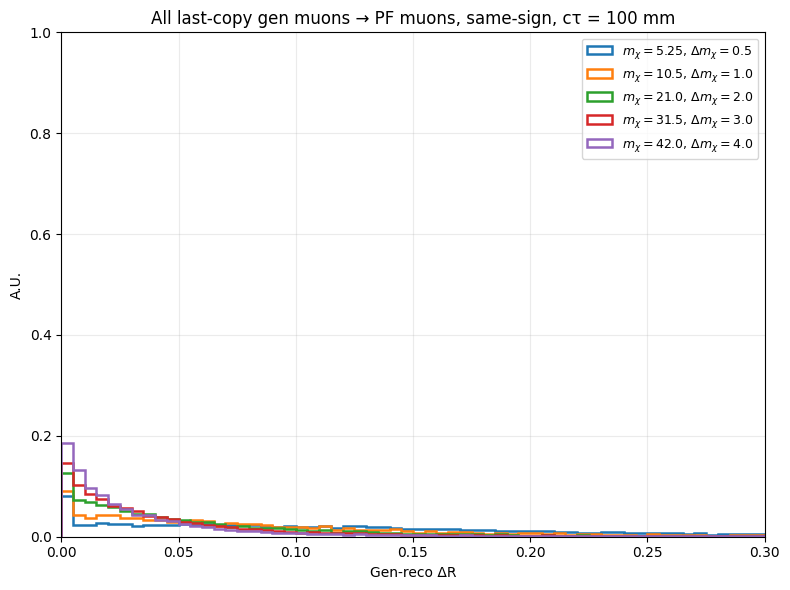

In [54]:
plot_gen_reco_dr_distribution(
    df_match,
    samples_to_plot=samples_ctau,
    collection="GenParticleLastCopy",
    reco="PF",
    normalize=True,
    x_max=0.3,
    title=f"All last-copy gen muons → PF muons, same-sign, cτ = {ctau} mm",
    outname=f"genRecoDr_GenParticleLastCopy_to_PF_ctau_{ctau}",
)

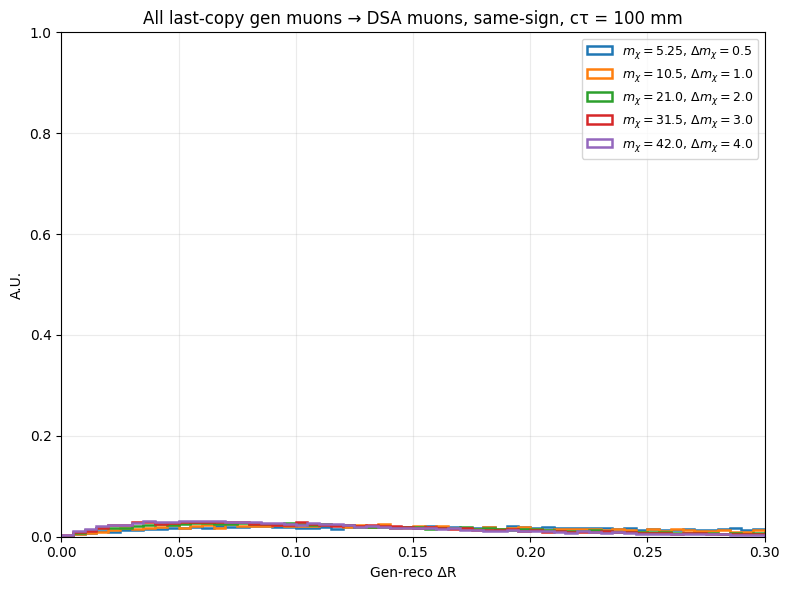

In [55]:
plot_gen_reco_dr_distribution(
    df_match,
    samples_to_plot=samples_ctau,
    collection="GenParticleLastCopy",
    reco="DSA",
    normalize=True,
    x_max=0.3,
    title=f"All last-copy gen muons → DSA muons, same-sign, cτ = {ctau} mm",
    outname=f"genRecoDr_GenParticleLastCopy_to_DSA_ctau_{ctau}",
)